### 1D Convergence study for SIAC

* Checks that the SIAC code achives expected convergence order of atleast $\mathcal{O}(h^{2p+1})$.
* For this, the modal DG basis is created using an exact $L^2$-projection

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [17]:
from src.verification.convergence_tools import run_convergence_study_1d
from src.mesh import build_uniform_mesh_1d
from src.grid import local_cell_center_nodes_1d, build_grid_from_local_nodes_1d
from src.projection_approach import l2_project_exact_func_to_dg_1d
from src.evaluation import eval_dg_on_local_nodes_1d
from src.siac_modal import apply_siac_to_modal_dg_1d, trim_valid_siac_region_1d

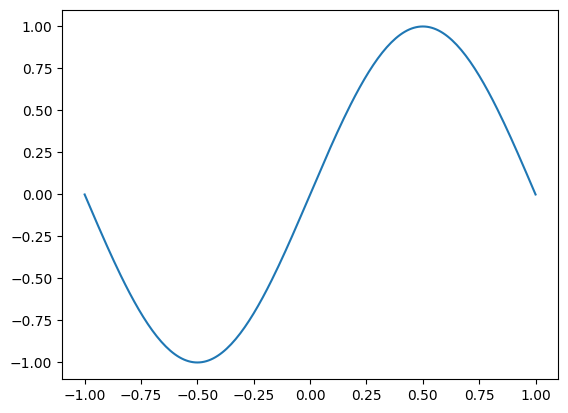

In [18]:
# Domain
xmin, xmax = -1, 1
xlim = (xmin, xmax)

def sine_func_1d(x):
    x = np.asarray(x)
    xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    return np.sin(np.pi*xhat)

x_vec = np.linspace(xlim[0], xlim[1], 201)
plt.plot(x_vec, sine_func_1d(x_vec))
plt.show()

In [19]:

K_list = 12 * 2**np.arange(8)

# Dg stuff
p = 2
order = p + 1

# Postprocessor
moments = 2*p
BSorder = p + 1



apply_noise = False

results = run_convergence_study_1d(
    exact_func=sine_func_1d,
    K_list=K_list,
    p=p,
    xlim=(-1, 1),
    moments=moments, 
    BSorder=BSorder,
    apply_noise=apply_noise,
    build_uniform_mesh_1d=build_uniform_mesh_1d,
    local_cell_center_nodes_1d=local_cell_center_nodes_1d,
    build_grid_from_local_nodes_1d=build_grid_from_local_nodes_1d,
    l2_project_exact_func_to_dg_1d=l2_project_exact_func_to_dg_1d,
    eval_dg_on_local_nodes_1d=eval_dg_on_local_nodes_1d,
    apply_siac_to_modal_dg_1d=apply_siac_to_modal_dg_1d,
    trim_valid_siac_region_1d=trim_valid_siac_region_1d,
)

hs = results["h"]
Ks = results["K"]

dg_max = results["dg_max"]
siac_max = results["siac_max"]

dg_rel_l2 = results["dg_rel_l2"]
siac_rel_l2 = results["siac_rel_l2"]

dg_max_rates = results["dg_max_rate"]
siac_max_rates = results["siac_max_rate"]

dg_l2_rates = results["dg_rel_l2_rate"]
siac_l2_rates = results["siac_rel_l2_rate"]

print("\nConvergence table:\n")
print(f"{'K':>6} {'h':>12} | {'DG max':>12} {'rate':>8} | {'SIAC max':>12} {'rate':>8} | {'DG L2':>12} {'rate':>8} | {'SIAC L2':>12} {'rate':>8}")
print("-"*110)

for i in range(len(Ks)):
    dg_max_r = "-" if np.isnan(dg_max_rates[i]) else f"{dg_max_rates[i]:.4f}"
    siac_max_r = "-" if np.isnan(siac_max_rates[i]) else f"{siac_max_rates[i]:.4f}"
    dg_l2_r = "-" if np.isnan(dg_l2_rates[i]) else f"{dg_l2_rates[i]:.4f}"
    siac_l2_r = "-" if np.isnan(siac_l2_rates[i]) else f"{siac_l2_rates[i]:.4f}"

    print(f"{Ks[i]:6d} {hs[i]:12.4e} | "
          f"{dg_max[i]:12.4e} {dg_max_r:>8} | "
          f"{siac_max[i]:12.4e} {siac_max_r:>8} | "
          f"{dg_rel_l2[i]:12.4e} {dg_l2_r:>8} | "
          f"{siac_rel_l2[i]:12.4e} {siac_l2_r:>8}")

Iteration 1 of 8, K = 12 
Iteration 2 of 8, K = 24 
Iteration 3 of 8, K = 48 
Iteration 4 of 8, K = 96 
Iteration 5 of 8, K = 192 
Iteration 6 of 8, K = 384 
Iteration 7 of 8, K = 768 
Iteration 8 of 8, K = 1536 

Convergence table:

     K            h |       DG max     rate |     SIAC max     rate |        DG L2     rate |      SIAC L2     rate
--------------------------------------------------------------------------------------------------------------
    12   1.6667e-01 |   1.1439e-03        - |   5.6907e-05        - |   7.0417e-04        - |   6.5500e-05        -
    24   8.3333e-02 |   1.4621e-04   2.9679 |   1.0675e-06   5.7363 |   4.5717e-05   3.9451 |   1.0637e-06   5.9443
    48   4.1667e-02 |   1.8378e-05   2.9920 |   1.6842e-08   5.9861 |   5.9753e-06   2.9356 |   1.6782e-08   5.9860
    96   2.0833e-02 |   2.3004e-06   2.9980 |   2.6379e-10   5.9965 |   8.0936e-07   2.8842 |   2.6286e-10   5.9965
   192   1.0417e-02 |   2.8765e-07   2.9995 |   4.1243e-12   5.9991 |   1.0

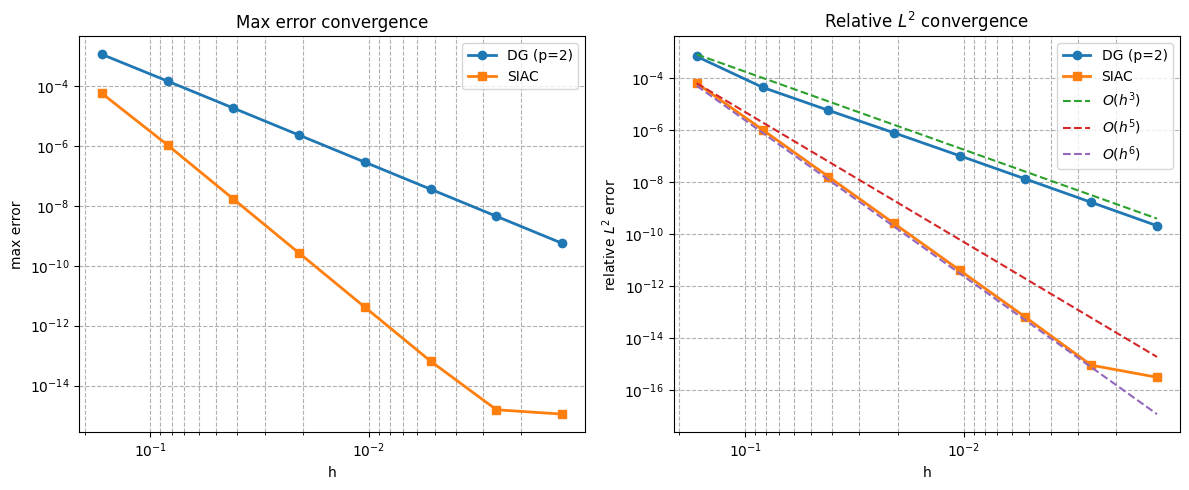

In [20]:
def add_reference_line(ax, h, err, order, label, scale=1.0):
    c = scale * err[0] / (h[0] ** order)
    ax.loglog(h, c * h**order, "--", label=label)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Max error ---
axs[0].loglog(hs, dg_max, "o-", linewidth=2, label=f"DG (p={p})")
axs[0].loglog(hs, siac_max, "s-", linewidth=2, label=f"SIAC")

axs[0].set_xlabel("h")
axs[0].set_ylabel("max error")
axs[0].set_title("Max error convergence")
axs[0].grid(True, which="both", ls="--")
axs[0].legend()

# --- Relative L2 ---
axs[1].loglog(hs, dg_rel_l2, "o-", linewidth=2, label=f"DG (p={p})")
axs[1].loglog(hs, siac_rel_l2, "s-", linewidth=2, label=f"SIAC")

axs[1].set_xlabel("h")
axs[1].set_ylabel("relative $L^2$ error")
axs[1].set_title("Relative $L^2$ convergence")
axs[1].grid(True, which="both", ls="--")

add_reference_line(axs[1], hs, dg_rel_l2, p + 1, rf"$O(h^{{{p+1}}})$", scale=1.2)
add_reference_line(axs[1], hs, siac_rel_l2, 2*p + 1, rf"$O(h^{{{2*p+1}}})$", scale=1.0)
add_reference_line(axs[1], hs, siac_rel_l2, 2*p + 2, rf"$O(h^{{{2*p+2}}})$", scale=0.8)

axs[1].legend()

axs[0].invert_xaxis()
axs[1].invert_xaxis()

plt.tight_layout()
plt.show()